In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
df = pd.read_csv("youtube_videos.csv")

In [106]:
df.head(10)

,video_id,title,description,published_at,viewCount,likeCount,commentCount,duration
0,UigGPZYdyoo,Just LEARN THESE 6 courses to Make Money Onlin...,"In this video, I break down how you can shift ...",2025-12-04 10:30:31+00:00,1831,120,15,603
1,n5Ev-klyqXc,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,"Don't forget to like, comment, and subscribe f...",2025-12-02 10:30:40+00:00,6310,588,20,78
2,fR-2AiAxDhk,"POV: I Made ₹2,687 in 60- Minutes from the Eas...","POV: I Made ₹2,687 in 1 hour from the Easiest ...",2025-11-27 10:30:27+00:00,5897,265,47,481
3,Ze1t4p0QCT0,"You know that phase when life says 'Bas, ho gy...","Don't forget to like, comment, and subscribe f...",2025-11-25 10:30:32+00:00,8944,666,4,61
4,Tr6Z8guOdM4,Complete Beginners Guide To Affinity Pixel Stu...,Complete Beginners Guide To Affinity Pixel Stu...,2025-11-20 10:30:31+00:00,2257,94,30,2140
5,0eIDN3uZiCg,I’m super excited for this new journey. I hope...,"Time for a cool introduction, right?\nWill the...",2025-11-18 10:30:01+00:00,15161,812,11,43
6,fbd903qIEns,7 Lessons for my Younger Self! (Watch this if ...,7 Things I wish I knew BEFORE 2025 started (My...,2025-11-13 10:30:25+00:00,3682,250,61,1152
7,fPpBv7UGHT4,"My story of comeback 💖 Reset, recharge but don...","Don't forget to like, comment, and subscribe f...",2025-11-11 10:30:24+00:00,10638,560,10,55
8,stegnhfnk6s,Complete Beginners Guide To 2025 🔥 Full Affin...,Complete Beginners Guide To 2025 🔥 Full Canva...,2025-11-06 10:30:43+00:00,31472,1155,123,1755
9,mcbAB1mNU7c,Design Your Portfolio on Behance in 30 Minutes...,Want to build a professional Behance portfolio...,2025-10-30 10:30:38+00:00,7322,306,42,1795


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      491 non-null    object
 1   title         491 non-null    object
 2   description   405 non-null    object
 3   published_at  491 non-null    object
 4   viewCount     491 non-null    int64 
 5   likeCount     491 non-null    int64 
 6   commentCount  491 non-null    int64 
 7   duration      491 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 30.8+ KB


In [108]:
df.describe()

,viewCount,likeCount,commentCount,duration
count,4.910000e+02,491.000000,491.000000,491.000000
mean,4.669661e+04,1785.690428,116.437882,819.087576
std,1.308113e+05,4487.456712,171.425326,1387.158621
min,8.930000e+02,40.000000,1.000000,11.000000
25%,6.108000e+03,362.500000,19.000000,59.000000
50%,1.214900e+04,682.000000,67.000000,552.000000
75%,3.163700e+04,1380.000000,146.000000,922.000000
max,1.785057e+06,72330.000000,2035.000000,19241.000000


In [109]:
df['published_at'] = pd.to_datetime(df['published_at'])

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      491 non-null    object             
 1   title         491 non-null    object             
 2   description   405 non-null    object             
 3   published_at  491 non-null    datetime64[ns, UTC]
 4   viewCount     491 non-null    int64              
 5   likeCount     491 non-null    int64              
 6   commentCount  491 non-null    int64              
 7   duration      491 non-null    int64              
dtypes: datetime64[ns, UTC](1), int64(4), object(3)
memory usage: 30.8+ KB


In [111]:
df.isnull().sum()

video_id         0
title            0
description     86
published_at     0
viewCount        0
likeCount        0
commentCount     0
duration         0
dtype: int64

In [112]:
df = df.drop(['video_id', 'description'], axis = 1)

In [113]:
df['title_length'] = df['title'].str.len()

In [114]:
df.head()

,title,published_at,viewCount,likeCount,commentCount,duration,title_length
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50
2,"POV: I Made ₹2,687 in 60- Minutes from the Eas...",2025-11-27 10:30:27+00:00,5897,265,47,481,72
3,"You know that phase when life says 'Bas, ho gy...",2025-11-25 10:30:32+00:00,8944,666,4,61,73
4,Complete Beginners Guide To Affinity Pixel Stu...,2025-11-20 10:30:31+00:00,2257,94,30,2140,95


In [115]:
df.dtypes

title                        object
published_at    datetime64[ns, UTC]
viewCount                     int64
likeCount                     int64
commentCount                  int64
duration                      int64
title_length                  int64
dtype: object

In [116]:
df['engagement_rate'] = (df['likeCount'] + df['commentCount']) / df['viewCount']

In [117]:
df['day_of_week'] = df['published_at'].dt.day_name()

In [118]:
df.head(2)

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55,0.073730,Thursday
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50,0.096355,Tuesday


In [119]:
df['hour'] = df['published_at'].dt.hour

### Views vs Posting hour


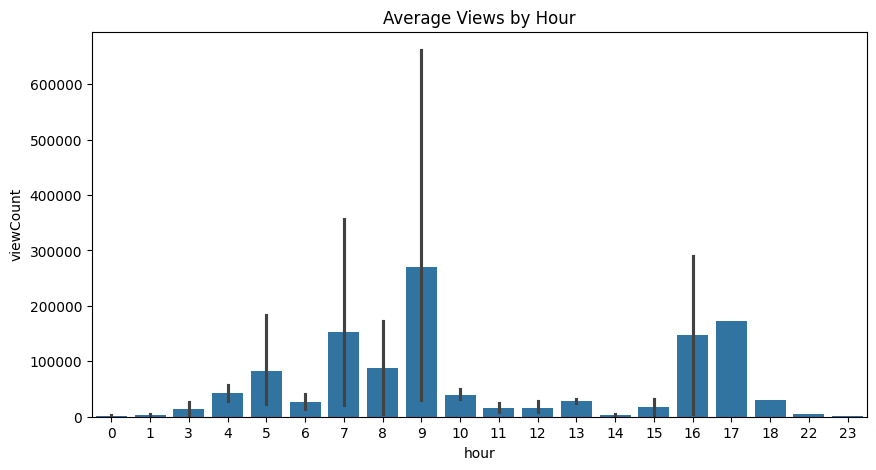

In [120]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'hour', y = 'viewCount', data = df)
plt.title("Average Views by Hour")
plt.show()

### Views vs Posting day

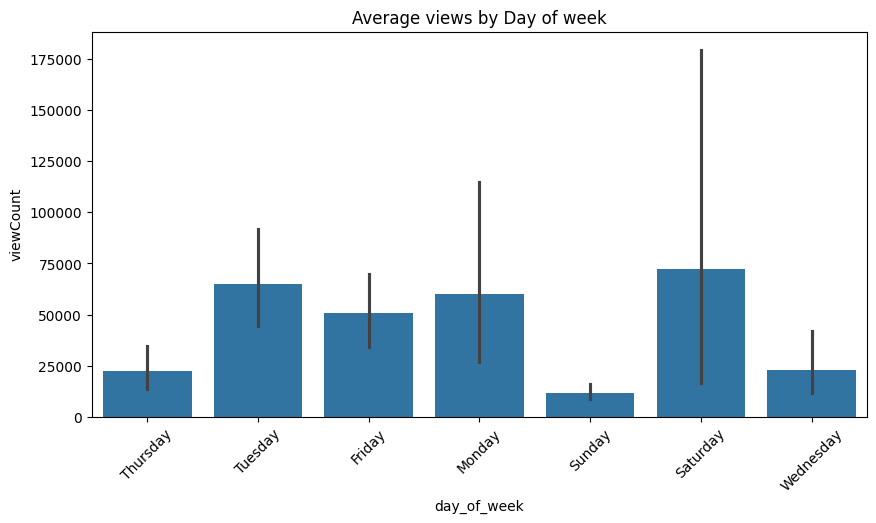

In [121]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'day_of_week', y = 'viewCount', data = df)
plt.title("Average views by Day of week")
plt.xticks(rotation = 45)
plt.show()

### Engagement Rate distribution

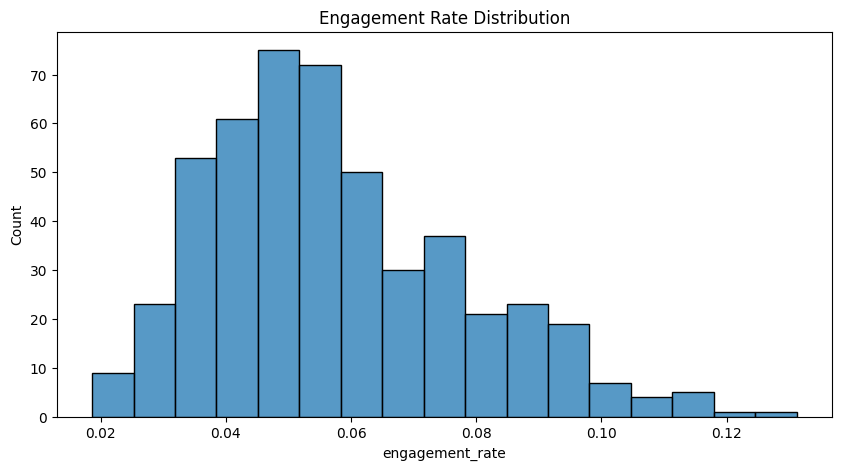

In [122]:
plt.figure(figsize = (10,5))
sns.histplot(df['engagement_rate'])
plt.title("Engagement Rate Distribution")
plt.show()

## ML modeling

### Outlier detection

In [123]:
def outlier_detect(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] < lower) | (df[column] > upper)]

outliers = outlier_detect(df, 'engagement_rate')
outliers.head()

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week,hour
82,10 FREE Graphic Design Tools!,2025-01-24 11:54:58+00:00,14094,1816,33,44,29,0.131191,Friday,11
135,5 Podcasts that every designer must listen 🎧,2024-10-12 04:30:10+00:00,2797,324,6,61,45,0.117984,Saturday,4
140,Freelancing Strategy for Beginners 🚀 #shorts #...,2024-10-04 10:30:32+00:00,3434,377,14,58,57,0.113861,Friday,10
147,This happened 🫠 #shorts,2024-09-07 04:35:00+00:00,8964,954,36,40,23,0.110442,Saturday,4
170,New Freelancers assemble here 🔥 #shorts,2024-07-18 06:23:40+00:00,14084,1563,27,39,39,0.112894,Thursday,6


In [124]:
outlierz = outlier_detect(df , 'viewCount')
outlierz[['title', 'viewCount']]

,title,viewCount
37,How to make money using Mobile Phone in 2025: ...,71141
45,Learn Photoshop in 60 Minutes | Photoshop Tuto...,149407
47,How to ACTUALLY Make Money with Copywriting in...,125873
70,Full Graphic Design Premium Crash Course for B...,513118
80,17 ways to make money using Canva + Roadmap (J...,90877
...,...,...
484,How To Rank Gig on Fiverr 2021| How to get 1st...,93286
485,HOW TO EARN MONEY WITH CANVA ON FIVERR | Freel...,171846
487,Fiverr tutorial for beginners | Part -2 | how ...,432315
488,How To Create Seller Account on Fiverr | Fiver...,548553


#### Visualizing outliers

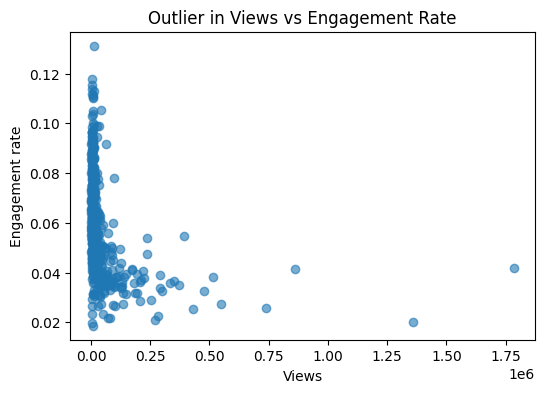

In [125]:
plt.figure(figsize = (6,4))
plt.scatter(df['viewCount'], df['engagement_rate'], alpha = 0.6)
plt.xlabel("Views")
plt.ylabel("Engagement rate")
plt.title("Outlier in Views vs Engagement Rate")
plt.show()

##### Shruti's videos show a clear negative trend between views and engagement.
##### Most videos with 0–200k views achieve stable engagement (3–6%), while viral videos (500k+ views) have lower engagement.


In [126]:
df.info

<bound method DataFrame.info of                                                  title  \
0    Just LEARN THESE 6 courses to Make Money Onlin...   
1    My journey ❤️🤍 I just felt like sharing 🫠❤️  #...   
2    POV: I Made ₹2,687 in 60- Minutes from the Eas...   
3    You know that phase when life says 'Bas, ho gy...   
4    Complete Beginners Guide To Affinity Pixel Stu...   
..                                                 ...   
486  How to Become A Content Writer? | Now get paid...   
487  Fiverr tutorial for beginners | Part -2 | how ...   
488  How To Create Seller Account on Fiverr | Fiver...   
489  Freelancing | freelancing skills | Best websit...   
490  I Earned $10 in just 30 minutes using Canva: L...   

                 published_at  viewCount  likeCount  commentCount  duration  \
0   2025-12-04 10:30:31+00:00       1831        120            15       603   
1   2025-12-02 10:30:40+00:00       6310        588            20        78   
2   2025-11-27 10:30:27+00:00     

In [127]:
df.head(2)

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week,hour
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55,0.073730,Thursday,10
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50,0.096355,Tuesday,10


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   title            491 non-null    object             
 1   published_at     491 non-null    datetime64[ns, UTC]
 2   viewCount        491 non-null    int64              
 3   likeCount        491 non-null    int64              
 4   commentCount     491 non-null    int64              
 5   duration         491 non-null    int64              
 6   title_length     491 non-null    int64              
 7   engagement_rate  491 non-null    float64            
 8   day_of_week      491 non-null    object             
 9   hour             491 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(5), object(2)
memory usage: 36.6+ KB


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [130]:
X = df[['title','title_length','day_of_week','hour']]
y_views = df['viewCount']
y_likes = df['likeCount']
y_comments = df['commentCount']

In [131]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


In [132]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

In [133]:
print(df['day_of_week'])

0       Thursday
1        Tuesday
2       Thursday
3        Tuesday
4       Thursday
         ...    
486    Wednesday
487     Saturday
488       Friday
489       Monday
490     Saturday
Name: day_of_week, Length: 491, dtype: object


In [134]:
prepro = ColumnTransformer(
    transformers= [
        ('text', TfidfVectorizer(stop_words = 'english', max_features=1000), 'title'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['day_of_week']),
        ('num', StandardScaler(), ['title_length', 'hour'])
        ], remainder = 'passthrough'
)

In [135]:
X_train, X_test, y_train_v, y_test_v = train_test_split(X, y_views, test_size = 0.2, random_state=42)
X_train, X_test, y_train_l, y_test_l = train_test_split(X, y_likes, test_size = 0.2, random_state=42)
X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_comments, test_size = 0.2, random_state=42)

In [136]:
view_model = Pipeline([
    ('prep' , prepro),
    ('regressor', RandomForestRegressor(n_estimators= 100, random_state= 42))
])

like_model = Pipeline([
    ('prep' , prepro),
    ('regressor', RandomForestRegressor(n_estimators= 100, random_state= 42))
])

comment_model = Pipeline([
    ('prep' , prepro),
    ('regressor', RandomForestRegressor(n_estimators= 100, random_state= 42))
])

In [137]:
view_model.fit(X_train, y_train_v)

,steps,"[('prep', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [138]:
like_model.fit(X_train, y_train_l)
comment_model.fit(X_train, y_train_c)

,steps,"[('prep', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [139]:
from sklearn.metrics import mean_absolute_error

def check_performance(model, X_test, y_test, name):
    preds = model.predict(X_test)
    print(f"----{name} Results----")
    print(f"Accuracy (r2): {r2_score(y_test, preds):.2f}")
    print(f"Avg Error(MAE): {mean_absolute_error(y_test, preds):,.0f}\n")

check_performance(view_model, X_test, y_test_v, "Views")
check_performance(like_model, X_test, y_test_l,"Likes")
check_performance(comment_model, X_test, y_test_c, "Comments")

----Views Results----
Accuracy (r2): -2.81
Avg Error(MAE): 56,392

----Likes Results----
Accuracy (r2): -3.45
Avg Error(MAE): 2,060

----Comments Results----
Accuracy (r2): -1.24
Avg Error(MAE): 91



In [140]:
tfidf_vectorizer = TfidfVectorizer(stop_words = 'english', max_features=500)
title_matrix = tfidf_vectorizer.fit_transform(df['title'])
kmeans = KMeans(n_clusters=5, random_state=42)
df['topic_cluster'] = kmeans.fit_predict(title_matrix)

In [141]:
analysis = df.groupby('topic_cluster')['viewCount'].mean().sort_values(ascending=False)
best_cluster = analysis.index[0]
sample_titles = df[df['topic_cluster'] == best_cluster]['title'].head(3).tolist()

In [142]:
print(f"Strategy Tip: Your topic group {best_cluster} is your goldmine")
print(f"Average views for this group: {analysis.iloc[0]:,.0f}")
print(f"You should make more videos similar to: {sample_titles}") 

Strategy Tip: Your topic group 4 is your goldmine
Average views for this group: 106,848
You should make more videos similar to: ['POV: I Made ₹2,687 in 60- Minutes from the Easiest Canva Order on Fiverr', 'POV: I made ₹3,469 using Fiverr and Canva (Full Breakdown)', 'POV: I Made ₹29,000 from the Easiest Canva Order on Fiverr']


In [143]:
def predict_performance(user_title, day = "Monday", hour = 18):
    input_data = pd.DataFrame({
        'title': [user_title],
        'title_length': [len(user_title)],
        'day_of_week' : [day],
        'hour' : [hour]
    })

    v = view_model.predict(input_data)[0]
    l = like_model.predict(input_data)[0]
    c = comment_model.predict(input_data)[0]


    print(f"Prediction for '{user_title}':")
    print(f"\nViews: {int(v):,}\nLikes: {int(l):,} \nComments: {int(c):,}")

    
predict_performance("I made 40 crore as a 19 year old")

Prediction for 'I made 40 crore as a 19 year old':

Views: 21,642
Likes: 1,286 
Comments: 50


In [144]:

cluster_4_videos = df[df['topic_cluster'] == 4]


print("--- Videos in Topic Cluster 4 ---")
print(cluster_4_videos['title'].to_string(index=False))

print(f"\nTotal videos in cluster 4: {len(cluster_4_videos)}")

--- Videos in Topic Cluster 4 ---
POV: I Made ₹2,687 in 60- Minutes from the Easi...
POV: I made ₹3,469 using Fiverr and Canva (Full...
POV: I Made ₹29,000 from the Easiest Canva Orde...
I Earned Rs 12,821 as a Canva Designer: Order o...
I Earned $150 in just 30 minutes using Canva: L...
I Paid 3 Designers On Fiverr To Design The SAME...
                  Fiverr Scams: The truth  #shorts
How to Create and Sell Carousels and Make money...
How I Earned $20 in 30 Minutes: Canva & Fiverr ...
Get your 1st order on Fiverr within a Month { I...
     Why Fiverr Isn't Getting Me Clients 😭 #shorts
How I Landed a Client WITHOUT Fiverr or Upwork ...
EARN Rs 1000/Day On Fiverr Easy Design Skills R...
 Top 10 Hidden Fiverr Gigs to Boost Your Income! 🚀
How I got my 1st Order on Fiverr within 2 Days ...
                      Fiverr is Saturated 🧐#shorts
I earned $90 using canva on Fiverr 🤯 {LIVE ORDE...
Fiverr tutorial for beginners | Complete Fiverr...
How to make money with Canva on Fiverr | Freela.

In [145]:
import joblib

In [146]:
joblib.dump(view_model, 'view_model.pkl')
joblib.dump(like_model, 'like_model.pkl')
joblib.dump(comment_model, 'comment_model.pkl')

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfdif_vectorizer.pkl')
joblib.dump(df, 'processed_data.pkl')

['processed_data.pkl']